### Figure 3A: Gamma-comparison to experiment

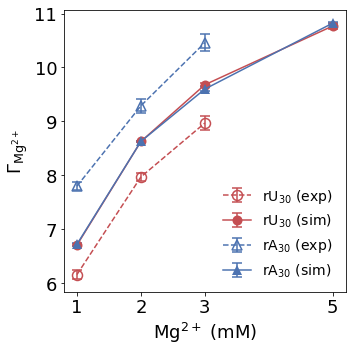

In [4]:
import os
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import seaborn as sns

curr_dir = os.getcwd()
dat_path = os.path.join(curr_dir, "gamma-simulation-vs-experiment.dat")

colnames = [
    "Mg_mM", "rA_sim", "rA_sim_err", "rA_exp", "rA_exp_err",
    "rU_sim", "rU_sim_err", "rU_exp", "rU_exp_err"
]

df = pd.read_csv(
    dat_path,
    sep=r"\s+",
    comment="#",
    names=colnames,
    na_values=["nan", "NaN"]
)

df_exp = df.dropna(subset=["rA_exp", "rU_exp"])
df_sim = df

plt.figure(figsize=(5, 5))
colors = sns.color_palette("deep")

rA_color = colors[0]
rU_color = colors[3]

plt.errorbar(
    np.array(df_exp["Mg_mM"]), np.array(df_exp["rU_exp"]), yerr=np.array(df_exp["rU_exp_err"]),
    label=r'rU$_{30}$ (exp)',
    fmt='o--', markerfacecolor="none",
    capsize=5, markersize=10,
    color=rU_color, markeredgecolor=rU_color,
    markeredgewidth=1.5, linewidth=1.5
)

plt.errorbar(
    np.array(df_sim["Mg_mM"]), np.array(df_sim["rU_sim"]), yerr=np.array(df_sim["rU_sim_err"]),
    label=r'rU$_{30}$ (sim)',
    fmt='o-', markersize=10, capsize=5,
    color=rU_color, markerfacecolor=rU_color,
    markeredgewidth=1.5, markeredgecolor='none',
    linewidth=1.5
)

plt.errorbar(
    np.array(df_exp["Mg_mM"]), np.array(df_exp["rA_exp"]), yerr=np.array(df_exp["rA_exp_err"]),
    label=r'rA$_{30}$ (exp)',
    fmt='^--', markerfacecolor="none",
    capsize=5, markersize=10,
    color=rA_color, markeredgecolor=rA_color,
    markeredgewidth=1.5, linewidth=1.5
)

plt.errorbar(
    np.array(df_sim["Mg_mM"]), np.array(df_sim["rA_sim"]), yerr=np.array(df_sim["rA_sim_err"]),
    label=r'rA$_{30}$ (sim)',
    fmt='^-', markersize=10, capsize=5,
    color=rA_color, markerfacecolor=rA_color,
    markeredgewidth=1.5, markeredgecolor='none',
    linewidth=1.5
)

plt.xticks(df["Mg_mM"])
plt.xlabel(r'$\mathrm{Mg}^{2+}$ (mM)', fontsize=18)
plt.ylabel(r'$\Gamma_{{\mathrm{Mg}}^{2+}}$', fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=18)
plt.legend(fontsize=14, loc="lower right", frameon=False)
plt.tight_layout()
plt.savefig("Fig3A.svg", dpi=300)
plt.show()

### Figure 3B: rA30-5mM-t20 inner, outer, and diffusive Mg

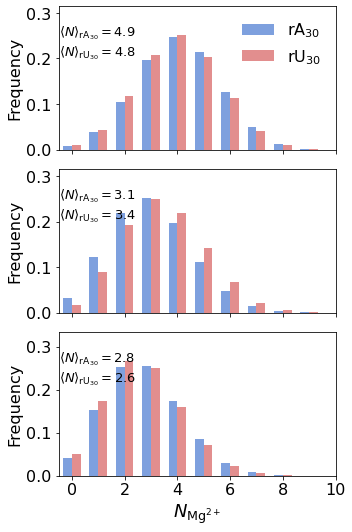

In [2]:
import os
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import seaborn as sns

curr_dir = os.getcwd()
colors = sns.color_palette("muted")
paths = {
    "rA": f"{curr_dir}/rA30-Na20-Mg5-t20",
    "rU": f"{curr_dir}/rU30-Na20-Mg5-t20",
}

# columns: inner, outer, diffusive
data = {}
for seq, path in paths.items():
    arr = np.loadtxt(f"{path}/hist_data_with_diffusive.dat", comments="#")
    data[seq] = {
        "inner": arr[:, 0],
        "outer": arr[:, 1],
        "diffusive": arr[:, 2],
    }

panel_order = ["diffusive", "inner", "outer"]
panel_labels = {
    "diffusive": "Diffusive Mg$^{2+}$",
    "inner": "Inner-shell Mg$^{2+}$",
    "outer": "Outer-shell Mg$^{2+}$",
}

fig, axes = plt.subplots(
    3, 1,
    figsize=(5, 7.5),
    sharex=True   # <-- share x-axis
)

dr = 1
bins = np.arange(0, 11, dr)  # fixed 0–10 bins

for ax, key in zip(axes, panel_order):

    hist_A, _ = np.histogram(data["rA"][key], bins=bins)
    hist_U, _ = np.histogram(data["rU"][key], bins=bins)

    freq_A = hist_A / hist_A.sum()
    freq_U = hist_U / hist_U.sum()

    mean_A = np.mean(data["rA"][key])
    mean_U = np.mean(data["rU"][key])

    ax.bar(
        bins[:-1] - dr / 3,
        freq_A,
        width=dr / 3,
        align="edge",
        label=r"rA$_{30}$",
        color=colors[0],
        alpha=0.7,
    )

    ax.bar(
        bins[:-1],
        freq_U,
        width=dr / 3,
        align="edge",
        label=r"rU$_{30}$",
        color=colors[3],
        alpha=0.7,
    )

    ax.text(
        0, 0.88,
        rf"$\langle N \rangle_{{\mathrm{{rA_{{30}}}}}} = {mean_A:.1f}$" + "\n" +
        rf"$\langle N \rangle_{{\mathrm{{rU_{{30}}}}}} = {mean_U:.1f}$",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=13,
    )

    ax.set_ylabel("Frequency", fontsize=16)
    #ax.set_title(panel_labels[key], fontsize=16)
    ax.tick_params(axis="both", which="major", labelsize=16)

    ax.set_xlim(-0.5, 10)
    ax.set_ylim(0, max(freq_A.max(), freq_U.max()) * 1.25)

# only bottom panel shows x-label
axes[-1].set_xlabel(r"$N_{\mathrm{Mg^{2+}}}$", fontsize=18)
axes[-1].set_xticks(np.arange(0, 11, 2))

axes[0].legend(frameon=False, fontsize=16)

plt.tight_layout()
plt.savefig("Fig3B.svg", dpi=300)
plt.show()